# Phase 1:  Data Exploration and Initial Analysis

## 1.1 Initial data review

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import re


In [3]:
df = pd.read_csv('football.csv')
df.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27.0,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,6.000000e+07
1,Hernán Crespo,Centre-Forward,25.0,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,5.681000e+07
2,Marc Overmars,Left Winger,27.0,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,4.000000e+07
3,Gabriel Batistuta,Centre-Forward,31.0,Fiorentina,Serie A,AS Rola,mhQdi,2000-2001,NaN,3.615000e+07
4,Nicolas Anelka,Centre-Forward,21.0,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,2.925040e+07


In [4]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 4700
Number of Columns: 10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          4660 non-null   object 
 1   Position      4667 non-null   object 
 2   Age           4616 non-null   float64
 3   Team_from     4663 non-null   object 
 4   League_from   4652 non-null   object 
 5   Team_to       4651 non-null   object 
 6   League_to     4666 non-null   object 
 7   Season        4647 non-null   object 
 8   Market_value  3379 non-null   float64
 9   Transfer_fee  4608 non-null   float64
dtypes: float64(3), object(7)
memory usage: 367.3+ KB


In [6]:
print("missing values for each column")
missing_values = df.isnull().sum()
print(missing_values)

missing values for each column
Name              40
Position          33
Age               84
Team_from         37
League_from       48
Team_to           49
League_to         34
Season            53
Market_value    1321
Transfer_fee      92
dtype: int64


In [7]:
# A high std in Transfer_fee means there is a huge gap between expensive players and cheap players.
stats = df.describe()
print(stats)

               Age  Market_value  Transfer_fee
count  4616.000000  3.379000e+03  4.608000e+03
mean     25.971224  9.026841e+06  1.001174e+07
std      16.786169  1.070848e+07  1.300129e+07
min       0.000000  5.000000e+04  8.250000e+05
25%      22.000000  3.500000e+06  4.000000e+06
50%      24.000000  6.337435e+06  6.500000e+06
75%      27.000000  1.038545e+07  1.100000e+07
max     288.704043  2.780097e+08  2.654239e+08


## 1.2 data visualization

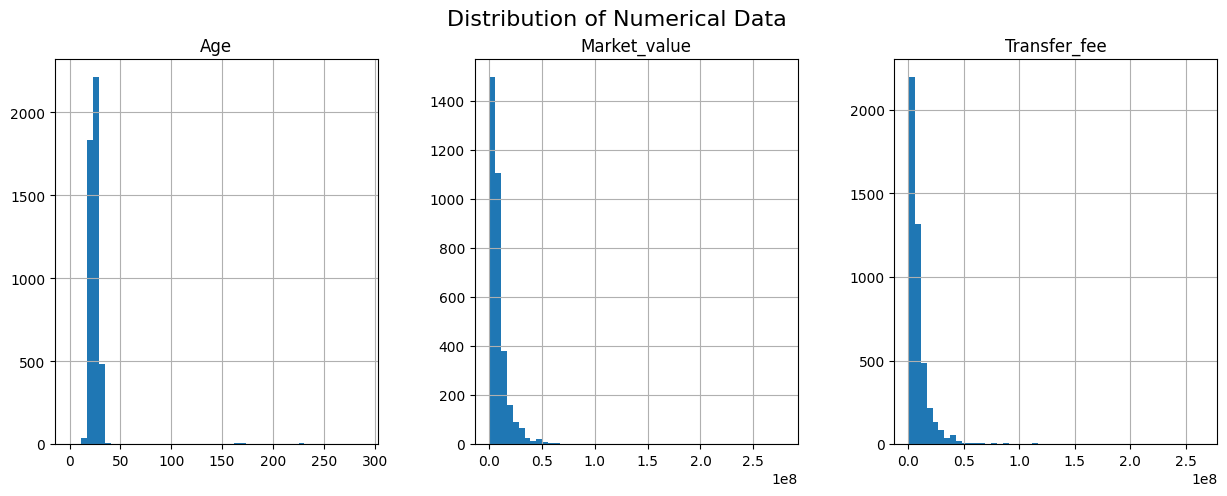

In [8]:
df[['Age', 'Market_value', 'Transfer_fee']].hist(bins=50, figsize=(15, 5), layout=(1, 3))
plt.suptitle('Distribution of Numerical Data', fontsize=16)
plt.show()

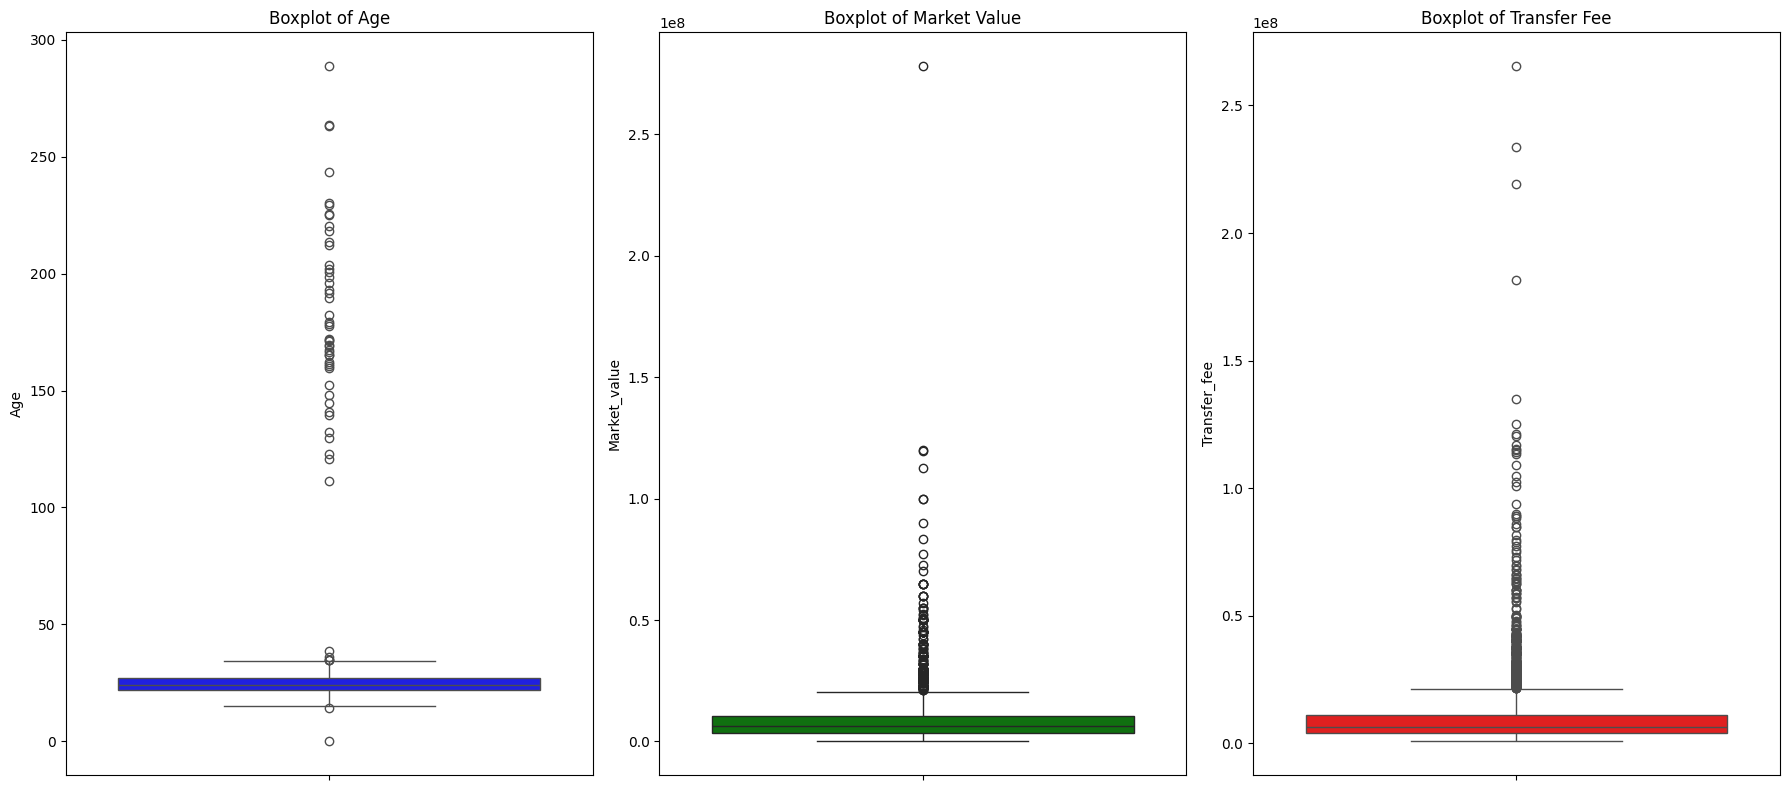

In [9]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Age'], color='blue')
plt.title('Boxplot of Age')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Market_value'], color='green')
plt.title('Boxplot of Market Value')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Transfer_fee'], color='red')
plt.title('Boxplot of Transfer Fee')

plt.tight_layout()
plt.show()

C:\Users\sasan_wmsfg3b\AppData\Local\Temp\ipykernel_2692\1293088044.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='Reds_r')


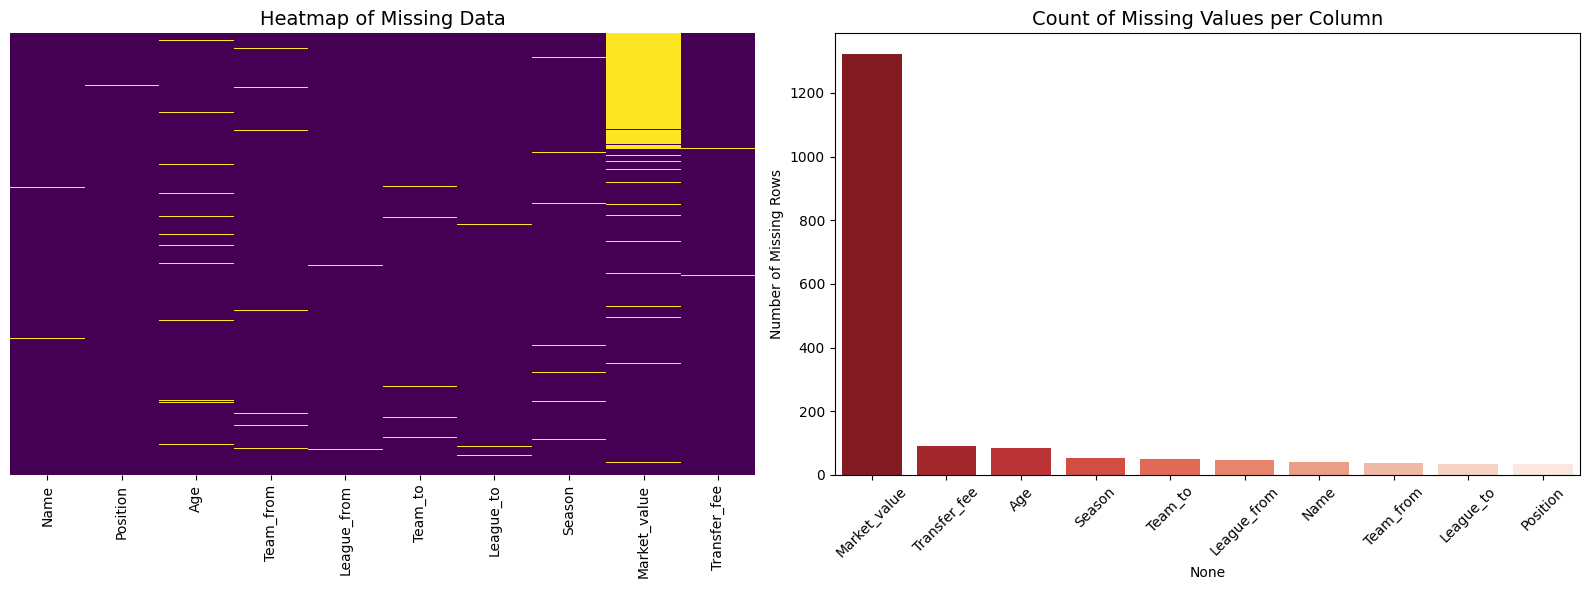

In [10]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Data', fontsize=14)

plt.subplot(1, 2, 2)
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='Reds_r')
plt.title('Count of Missing Values per Column', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Number of Missing Rows')

plt.tight_layout()
plt.show()

## 1.3 Examining relationships between variables

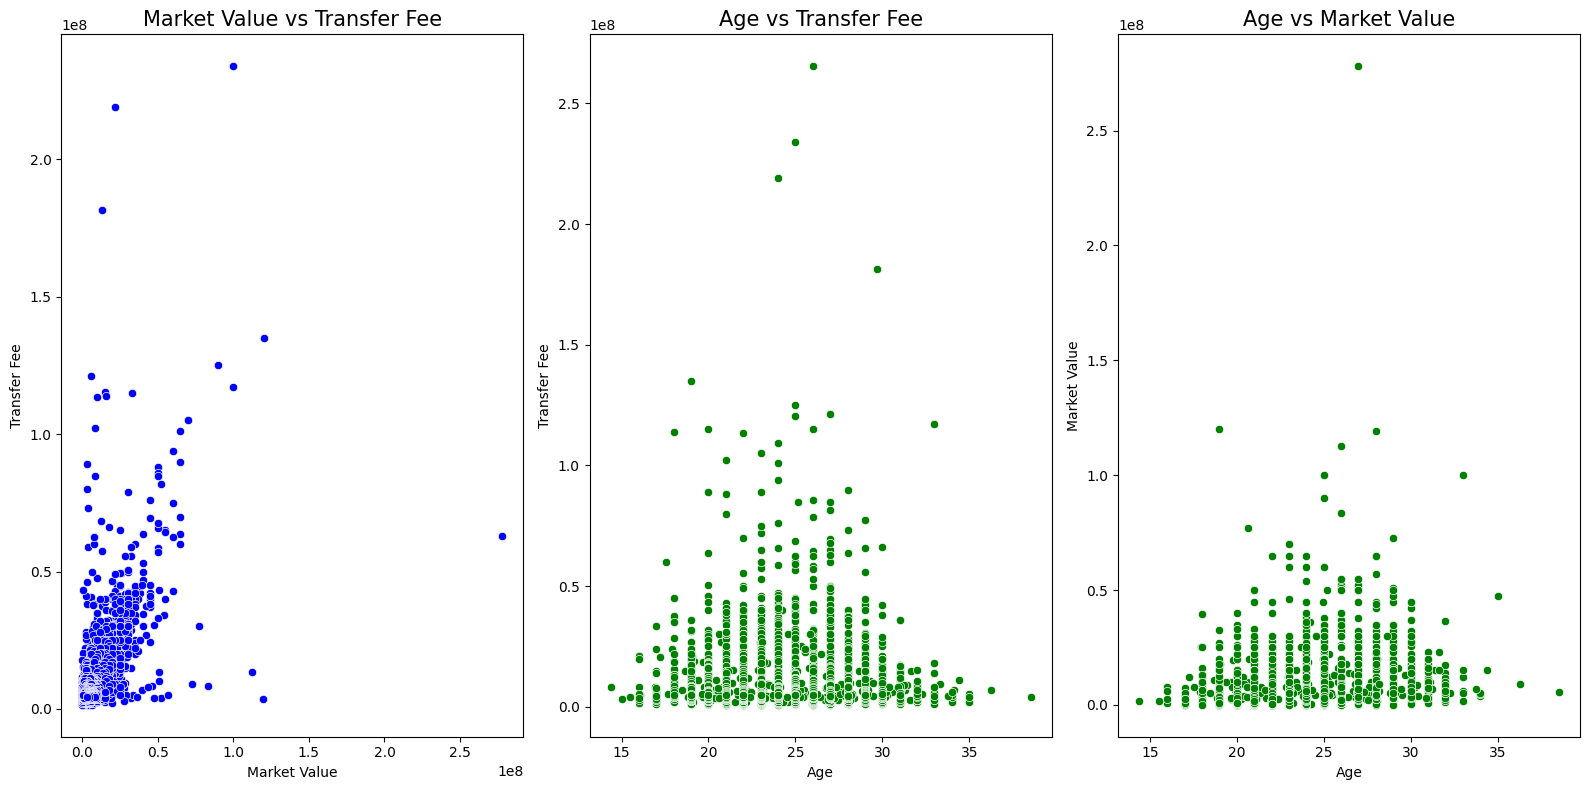

In [11]:
plt.figure(figsize=(16, 8))

# We expect a strong positive relationship (diagonal line going up)
plt.subplot(1, 3, 1)
sns.scatterplot(x=df['Market_value'], y=df['Transfer_fee'], color='blue')
plt.title('Market Value vs Transfer Fee', fontsize=15)
plt.xlabel('Market Value')
plt.ylabel('Transfer Fee')

# We generally expect a "hill" shape (values rise until mid-20s, then drop)
plt.subplot(1, 3, 2)
temp_df = df[(df['Age'] > 0) & (df['Age'] < 100)]
sns.scatterplot(x=temp_df['Age'], y=temp_df['Transfer_fee'], color='green')
plt.title('Age vs Transfer Fee', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Transfer Fee')

plt.subplot(1, 3, 3)
temp_df = df[(df['Age'] > 0) & (df['Age'] < 100)]
sns.scatterplot(x=temp_df['Age'], y=temp_df['Market_value'], color='green')
plt.title('Age vs Market Value', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Market Value')

plt.tight_layout()
plt.show()

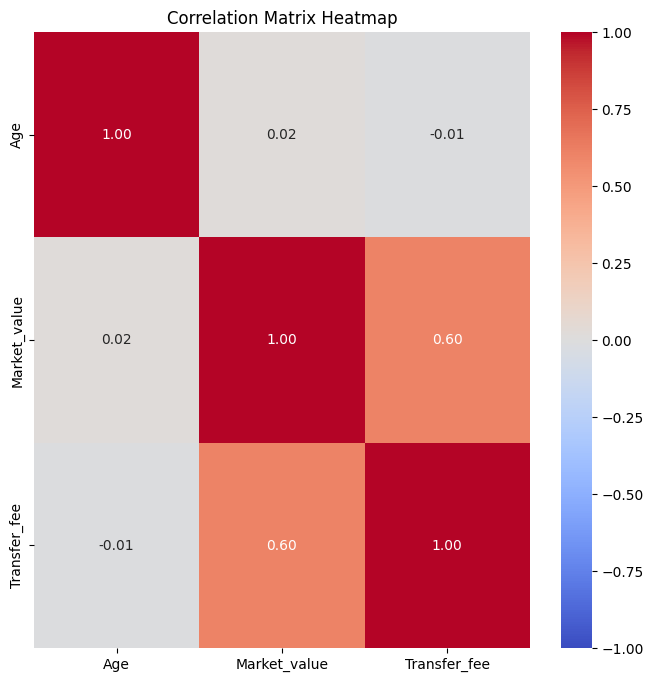

In [12]:
numeric_df = df.select_dtypes(include=['number'])

# correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

---
# Phase 2: Data Quality Assessment

## 2.1 Defining and calculating data quality metrics

<div dir="rtl" style="text-align: right; line-height: 1.6;">

<h3>۱. دقت (Accuracy)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار نشان می‌دهد که داده‌های ذخیره شده تا چه حد با واقعیت (دنیای واقعی) مطابقت دارند.</li>
  <li><strong>در پروژه ما:</strong> به عنوان مثال، در ستون «سن» (Age)، وجود مقدار <code>288</code> یا <code>0</code> دقت داده‌ها را پایین می‌آورد، زیرا هیچ بازیکن فوتبالی در دنیای واقعی ۲۸۸ ساله یا ۰ ساله نیست. محاسبه دقت یعنی بررسی اینکه چه درصدی از بازیکنان سن واقعی و منطقی (مثلاً بین ۱۵ تا ۴۵ سال) دارند.</li>
</ul>

<h3>۲. کامل بودن (Completeness)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار به درصدی از داده‌ها اشاره دارد که در دیتاست موجود هستند و خالی (Null/Missing) نیستند.</li>
  <li><strong>در پروژه ما:</strong> ما مشاهده کردیم که ستون <code>Market_value</code> دارای مقادیر خالی (NaN) زیادی است. اگر ۳۰٪ از سلول‌های این ستون خالی باشند، امتیاز «کامل بودن» برای این ستون ۷۰٪ خواهد بود. هدف ما داشتن دیتاستی با کمترین مقدار گمشده است.</li>
</ul>

<h3>۳. معتبر بودن (Validity)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار بررسی می‌کند که آیا داده‌ها از نظر فرمت، نوع (Type) و قواعد نحوی (Syntax) صحیح هستند یا خیر.</li>
  <li><strong>در پروژه ما:</strong> مبلغ قرارداد (<code>Transfer_fee</code>) باید همواره یک عدد مثبت باشد. اگر عددی منفی باشد یا به جای عدد، حروف متنی نوشته شده باشد، آن داده معتبر نیست (Invalid). همچنین فرمت ستون فصل (<code>Season</code>) باید به صورت استاندارد (مثلاً "2000-2001") باشد.</li>
</ul>

<h3>۴. به‌روز بودن (Currentness / Timeliness)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار نشان می‌دهد که داده‌ها تا چه حد جدید هستند و آیا برای زمان حال قابل استفاده‌اند یا خیر.</li>
  <li><strong>در پروژه ما:</strong> از آنجا که این یک دیتاست تاریخی است، «به‌روز بودن» به این معنی است که بازه زمانی داده‌ها (ستون Season) مشخص و قابل استناد باشد تا بتوانیم تحلیل روند (Trend Analysis) درستی انجام دهیم.</li>
</ul>

<h3>۵. سازگاری (Consistency)</h3>
<ul>
  <li><strong>تعریف:</strong> این معیار به معنای عدم وجود تناقض در داده‌هاست. داده‌ها باید در تمام بخش‌های پایگاه داده یکپارچه باشند.</li>
  <li><strong>در پروژه ما:</strong> مهم‌ترین فاکتور سازگاری، عدم وجود «داده‌های تکراری» (Duplicates) است. اگر اطلاعات انتقال یک بازیکن خاص دقیقاً دو بار در دیتاست تکرار شده باشد، ناسازگاری ایجاد شده و باعث خطا در محاسبات آماری می‌شود.</li>
</ul>

</div>

In [ ]:
print("DATA QUALITY STATISTICS REPORT")
print(f"Total Rows in Dataset: {df.shape[0]}")
print("\n")

age_errors = df[(df['Age'] < 15) | (df['Age'] > 45)]
count_age_errors = len(age_errors)

valid_positions = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]
unknown_positions = df[~df['Position'].isin(valid_positions) & df['Position'].notnull()]

short_teams_from = df[df['Team_from'].str.len() < 3]

short_teams_to = df[df['Team_to'].str.len() < 3]

short_leagues_from = df[df['League_from'].str.len() < 3]

short_leagues_to = df[df['League_to'].str.len() < 3]

name_errors = df[df['Name'].str.contains(r'[\d@#\$%\^&\*]', regex=True, na=False)]

print(f"1. ACCURACY:")
print(f"   - Accuracy for Name: {(len(df['Name'])-len(name_errors))/len(df['Name'])}")
print(f"   - Accuracy for position: {(len(df['Position'])-len(unknown_positions))/len(df['Position'])}")
print(f"   - Accuracy for age: {(len(df['Age'])-count_age_errors)/len(df['Age'])}")
print(f"   - Accuracy for TeamFrom: {(len(df['Team_from'])-len(short_teams_from))/len(df['Team_from'])}")
print(f"   - Accuracy for LeagueFrom: {(len(df['League_from'])-len(short_leagues_from))/len(df['League_from'])}")
print(f"   - Accuracy for TeamTo: {(len(df['Team_to'])-len(short_teams_from))/len(df['Team_to'])}")
print(f"   - Accuracy for LeagueTo: {(len(df['League_to'])-len(short_leagues_from))/len(df['League_to'])}")


# Count total missing values across the whole table
total_cells = df.size
total_missing_cells = df.isnull().sum().sum()
missing_market_value = df['Market_value'].isnull().sum()
print(f"\n2. COMPLETENESS:")
print(f"   - Total Missing Cells: {total_missing_cells}")
print(f"   - Missing 'Market_value' Count: {missing_market_value}")
print(f"   - Missing 'Age' Count: {df['Age'].isnull().sum()}")
print(f"   - Missing 'Name' Count: {df['Name'].isnull().sum()}")
print(f"   - Missing 'position' Count: {df['Position'].isnull().sum()}")
print(f"   - Missing 'teamFrom' Count: {df['Team_from'].isnull().sum()}")
print(f"   - Missing 'leagueFrom' Count: {df['League_from'].isnull().sum()}")

# Logic A: Transfer fee cannot be negative.
negative_fees = len(df[df['Transfer_fee'] < 0])
negative_value = len(df[df['Market_value'] < 0])

valid_season_pattern = r'^\d{4}-\d{4}$'
valid_seasons_mask = df['Season'].astype(str).str.match(valid_season_pattern)
invalid_seasons_count = df.shape[0] - valid_seasons_mask.sum()

print(f"\n3. VALIDITY & CURRENTNESS:")
print(f"   - Negative Transfer Fees (Count): {negative_fees}")
print(f"   - Negative Market Value (Count): {negative_value}")
print(f"   - Invalid Season Formats (Count): {invalid_seasons_count}")

duplicate_rows = df.duplicated().sum()
print(f"\n4. CONSISTENCY:")
print(f"   - Duplicate Rows Found: {duplicate_rows}")

DATA QUALITY STATISTICS REPORT
Total Rows in Dataset: 4700


1. ACCURACY:
   - Accuracy for Name: 0.987872340425532
   - Accuracy for position: 0.9178723404255319
   - Accuracy for age: 0.9895744680851064
   - Accuracy for TeamFrom: 0.9985106382978723
   - Accuracy for LeagueFrom: 0.9989361702127659
   - Accuracy for TeamTo: 0.9985106382978723
   - Accuracy for LeagueTo: 0.9989361702127659

2. COMPLETENESS:
   - Total Missing Cells: 1791
   - Missing 'Market_value' Count: 1321
   - Missing 'Age' Count: 84
   - Missing 'Name' Count: 40
   - Missing 'position' Count: 33
   - Missing 'teamFrom' Count: 37
   - Missing 'leagueFrom' Count: 48

3. VALIDITY & CURRENTNESS:
   - Negative Transfer Fees (Count): 0
   - Negative Market Value (Count): 0
   - Invalid Season Formats (Count): 336

4. CONSISTENCY:
   - Duplicate Rows Found: 0


## 2.2 Identify data quality problems

In [14]:
print("=== DETAILED COLUMN QUALITY AUDIT ===\n")

# 1. COLUMN: NAME
missing_names = df['Name'].isnull().sum()
invalid_name_pattern = r'[\d@#\$%\^&\*]'
invalid_names = df[df['Name'].str.contains(invalid_name_pattern, regex=True, na=False)]

print(f"[Name] Missing Values: {missing_names}")
print(f"[Name] Rows with numbers or special symbols: {len(invalid_names)}")
if len(invalid_names) > 0:
    print(f"   -> Examples: {invalid_names['Name'].head(3).tolist()}")

# 2. COLUMN: AGE
missing_age = df['Age'].isnull().sum()

if pd.api.types.is_numeric_dtype(df['Age']):
    non_numeric_age_count = 0 
else:
    non_numeric_age_count = df['Age'].astype(str).str.contains(r'[^0-9\.]', regex=True).sum()

decimal_age_count = (df['Age'].dropna() % 1 != 0).sum()

age_outliers = df[(df['Age'] < 15) | (df['Age'] > 50)]

print(f"\n[Age] Missing Values: {missing_age}")
print(f"[Age] Rows with non-numeric chars (@#$ etc): {non_numeric_age_count}")
print(f"[Age] Rows with decimal values (Floats): {decimal_age_count}")
print(f"[Age] Impossible Ages (<15 or >50): {len(age_outliers)} rows")
if len(age_outliers) > 0:
    print(f"   -> Examples: {age_outliers['Age'].unique().tolist()}")

# 3. COLUMN: POSITION
valid_positions = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]

missing_pos = df['Position'].isnull().sum()
unknown_pos = df[~df['Position'].isin(valid_positions) & df['Position'].notnull()]
garbage_pos = df[df['Position'].astype(str).str.contains(r'[\d@#\$%\^&\*]', regex=True, na=False)]

print(f"\n[Position] Missing values: {missing_pos}")
print(f"[Position] Unknown Positions (Not in valid list): {len(unknown_pos)}")
print(f"[Position] Rows with numbers or special symbols (@#$ etc): {len(garbage_pos)}")

if len(unknown_pos) > 0:
    print(f"   -> Examples of Unknown/Invalid: {unknown_pos['Position'].unique().tolist()}")

# 4. COLUMNS: LEAGUE FROM/TO & TEAM FROM/TO
target_cols = ['League_from', 'League_to', 'Team_from', 'Team_to']
invalid_text_pattern = r'[\d@#\$%\^&\*]'

print(f"\n[Leagues & Teams] Detailed Audit:")

for col in target_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        invalid_rows = df[df[col].astype(str).str.contains(invalid_text_pattern, regex=True, na=False)]
        
        print(f"   -- {col} --")
        print(f"      Missing Values: {missing_count}")
        print(f"      Rows with numbers or special symbols: {len(invalid_rows)}")
        
        if len(invalid_rows) > 0:
            print(f"      -> Examples: {invalid_rows[col].unique()[:3].tolist()}")
    else:
        print(f"   -- {col} NOT FOUND in DataFrame --")

# 5. COLUMN: SEASON
missing_seasons = df['Season'].isnull().sum()
garbage_seasons = df[df['Season'].astype(str).str.contains(r'[^0-9-]', regex=True, na=False)]

valid_format_rows = df[df['Season'].astype(str).str.match(r'^\d{4}-\d{4}$', na=False)].copy()
split_seasons = valid_format_rows['Season'].str.split('-', expand=True).astype(int)
logic_errors = valid_format_rows[split_seasons[0] >= split_seasons[1]]

print(f"\n[Season] Missing Values: {missing_seasons}")
print(f"[Season] Rows with invalid chars (not 0-9 or '-'): {len(garbage_seasons)}")
print(f"[Season] Rows with logic error (Start Year >= End Year): {len(logic_errors)}")

if len(garbage_seasons) > 0:
    print(f"   -> Examples of invalid chars: {garbage_seasons['Season'].unique()[:3].tolist()}")
if len(logic_errors) > 0:
    print(f"   -> Examples of logic errors: {logic_errors['Season'].unique()[:3].tolist()}")

# 6. COLUMN: MARKET_VALUE
missing_mv = df['Market_value'].isnull().sum()
print(f"\n[Market_value] Missing Values: {missing_mv} ({missing_mv/len(df)*100:.1f}%)")
print(f"[Market_value] Negative Values: {negative_value}")


# 7. COLUMN: TRANSFER_FEE
missing_tf = df['Transfer_fee'].isnull().sum()
print(f"\n[Transfer_fee] Missing Values: {missing_tf} ({missing_tf/len(df)*100:.1f}%)")
print(f"[Transfer_fee] Negative Values: {negative_fees}")

print("\n=== END OF AUDIT ===")

=== DETAILED COLUMN QUALITY AUDIT ===

[Name] Missing Values: 40
[Name] Rows with numbers or special symbols: 57
   -> Examples: ['nlr3H', 'xCE7y', '4DJBL']

[Age] Missing Values: 84
[Age] Rows with non-numeric chars (@#$ etc): 0
[Age] Rows with decimal values (Floats): 232
[Age] Impossible Ages (<15 or >50): 49 rows
   -> Examples: [129.76185367702797, 0.0, 200.4790967215486, 165.27635677717558, 195.79584950678057, 162.03506184924635, 167.20748232955918, 263.0002778575076, 132.08387091009132, 191.6479095397681, 169.11510445637143, 218.16177191069917, 201.96081280996285, 220.20245191608973, 230.3661214270035, 171.5070897032562, 140.88495986849415, 172.06219790855675, 111.19979175029268, 159.72356471545015, 177.5709499277201, 166.3302364129209, 243.4060721729823, 263.4972190291763, 189.70778339042968, 122.79673840203972, 212.1269676244085, 148.02655928543112, 182.44543630334897, 225.21187641140995, 139.63871314388453, 203.6178558474855, 288.7040427417844, 160.39635656270778, 120.9200563

C:\Users\sasan_wmsfg3b\AppData\Local\Temp\ipykernel_2692\285173133.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(missing_data.keys()), y=list(missing_data.values()), palette='Reds_r')


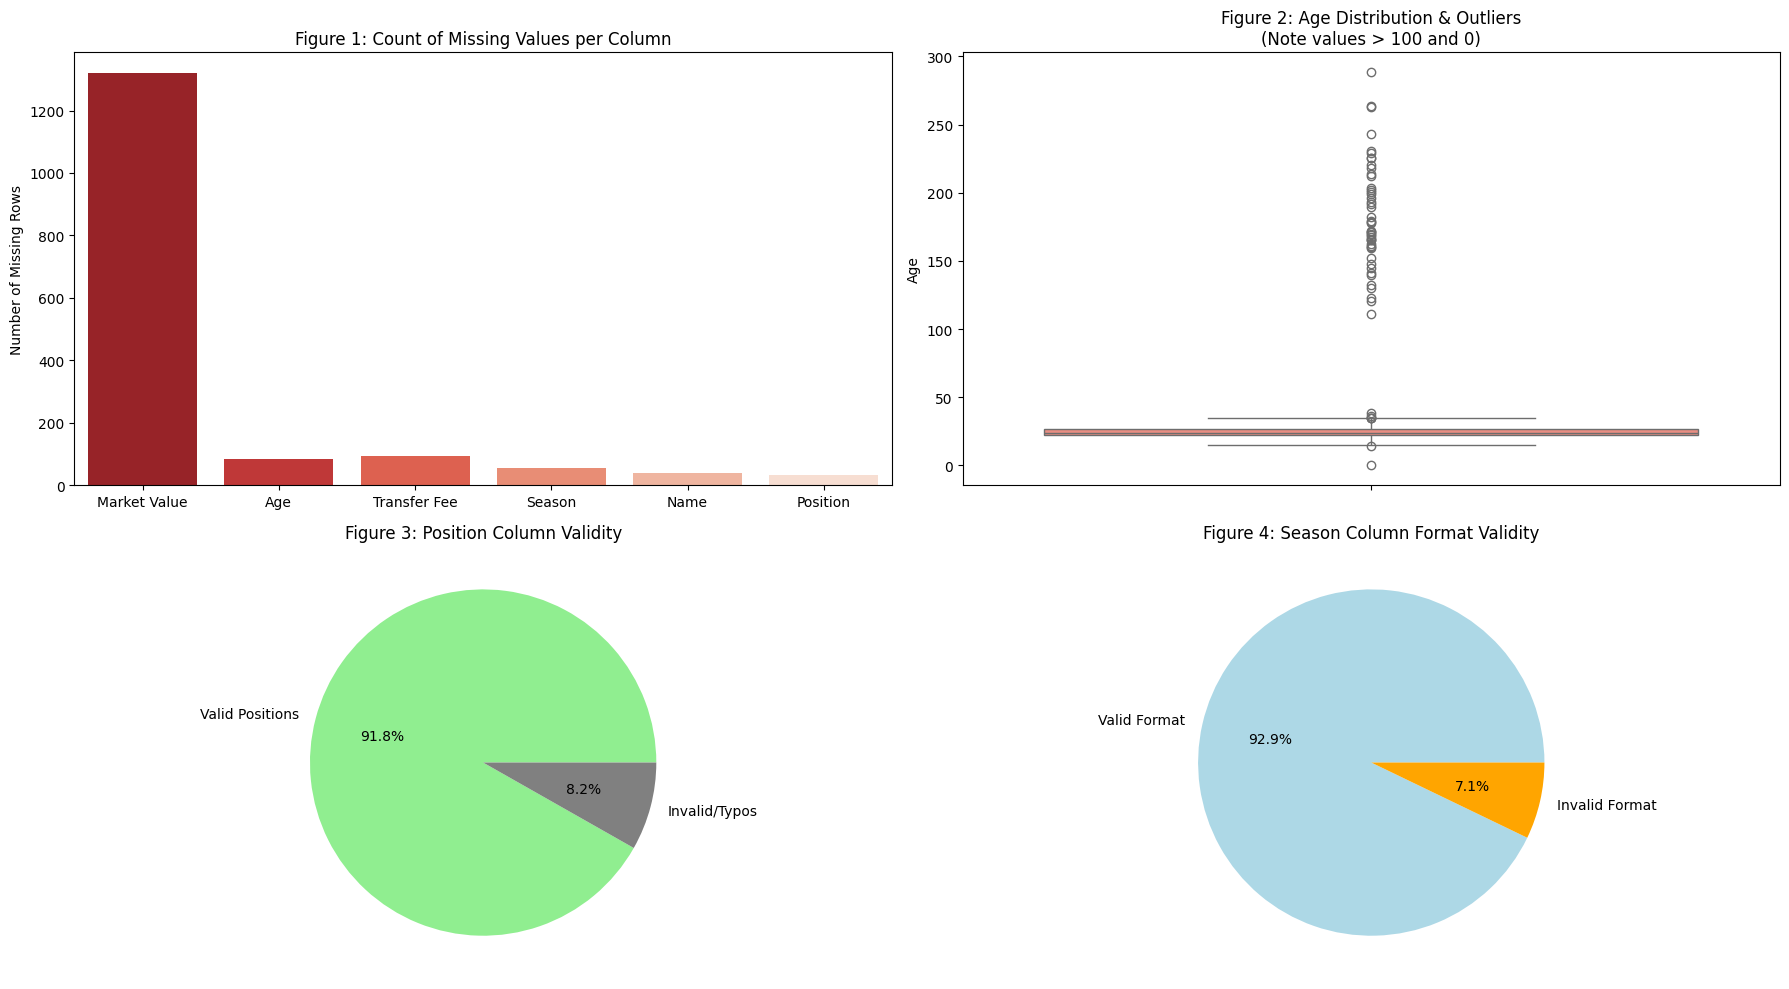

In [15]:
missing_data = {
    'Market Value': 1321,
    'Age': 84,
    'Transfer Fee': 92,
    'Season': 53,
    'Name': 40,
    'Position': 33
}

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
sns.barplot(x=list(missing_data.keys()), y=list(missing_data.values()), palette='Reds_r')
plt.title('Figure 1: Count of Missing Values per Column', fontsize=12)
plt.ylabel('Number of Missing Rows')

plt.subplot(2, 2, 2)
sns.boxplot(y=df['Age'], color='salmon')
plt.title('Figure 2: Age Distribution & Outliers\n(Note values > 100 and 0)', fontsize=12)

plt.subplot(2, 2, 3)
pos_quality = [len(df) - 386, 386]
plt.pie(pos_quality, labels=['Valid Positions', 'Invalid/Typos'], autopct='%1.1f%%', colors=['lightgreen', 'gray'])
plt.title('Figure 3: Position Column Validity', fontsize=12)

plt.subplot(2, 2, 4)
season_quality = [len(df) - 336, 336]
plt.pie(season_quality, labels=['Valid Format', 'Invalid Format'], autopct='%1.1f%%', colors=['lightblue', 'orange'])
plt.title('Figure 4: Season Column Format Validity', fontsize=12)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; line-height: 1.8;">

<h2>گزارش تفصیلی کیفیت داده‌ها (Data Quality Report)</h2>
<p>این گزارش بر اساس ممیزی دقیق ستون‌ها (Column Audit) و تحلیل بصری نمودارها تهیه شده است. مشکلات شناسایی شده در جدول زیر خلاصه شده‌اند:</p>

<hr>

<h3>۱. تحلیل ستون‌های هویتی (Name, Age, Position)</h3>

<h4>الف) نام بازیکن (Name)</h4>
<ul>
  <li><strong>مشکل:</strong> وجود کاراکترهای غیرمجاز و داده‌های خراب.</li>
  <li><strong>شواهد آماری:</strong> ۵۷ رکورد حاوی اعداد یا کاراکترهای خاص (مانند <code>xCE7y</code>) هستند که نشان‌دهنده خطای سیستم یا انکدینگ است. ۴۰ رکورد نیز کاملاً خالی هستند.</li>
</ul>

<h4>ب) سن (Age) [شکل ۲]</h4>
<ul>
  <li><strong>مشکل:</strong> داده‌های پرت و فرمت اعشاری.</li>
  <li><strong>شواهد آماری:</strong>
    <ul>
      <li><strong>۴۹ رکورد غیرمنطقی:</strong> سنین بالای ۵۰ سال (حتی تا ۲۸۸ سال!) و سن ۰.</li>
      <li><strong>۲۳۲ رکورد اعشاری:</strong> اعدادی مانند <code>129.76</code> که نشان‌دهنده خطای محاسباتی یا نرمال‌سازی غلط در دیتابیس مرجع است.</li>
    </ul>
  </li>
</ul>

<h4>ج) پست بازی (Position) [شکل ۳]</h4>
<ul>
  <li><strong>مشکل:</strong> غلط‌های املایی فراوان (Typos).</li>
  <li><strong>شواهد آماری:</strong> ۳۸۶ رکورد دارای مقادیری خارج از لیست استاندارد هستند. مثال‌هایی مانند <code>heft Winger</code> (به جای Left) یا <code>Goalkeeeer</code> نشان‌دهنده خطای تایپی یا OCR است.</li>
</ul>

<hr>

<h3>۲. تحلیل ستون‌های دسته‌بندی (Leagues, Teams, Season)</h3>

<h4>الف) لیگ‌ها و تیم‌ها (Leagues & Teams)</h4>
<ul>
  <li><strong>مشکل:</strong> ترکیب متن معتبر با داده‌های خراب (Garbage Text).</li>
  <li><strong>تحلیل:</strong> اسکریپت بازرسی، ۹۳۴ مورد را در <code>League_from</code> علامت‌گذاری کرد.
    <ul>
      <li>برخی موارد معتبر هستند (مانند <code>Ligue 1</code> که عدد دارد).</li>
      <li>برخی موارد خراب هستند (مانند <code>TTZi7</code> یا <code>0xvNK</code>).</li>
    </ul>
  </li>
  <li><strong>اقدام:</strong> در مرحله پاکسازی باید فقط متون بی‌معنی حذف شوند، نه لیگ‌هایی که ذاتاً عدد دارند.</li>
</ul>

<h4>ب) فصل (Season) [شکل ۴]</h4>
<ul>
  <li><strong>مشکل:</strong> فرمت نامعتبر.</li>
  <li><strong>شواهد آماری:</strong> ۳۳۶ رکورد (حدود ۷٪) فرمت استاندارد <code>YYYY-YYYY</code> را رعایت نکرده‌اند. وجود مقادیری مثل <code>nan</code> یا کاراکترهای درهم‌ریخته مانع از تحلیل زمانی می‌شود.</li>
</ul>

<hr>

<h3>۳. تحلیل ستون‌های مالی (Financial Columns)</h3>

<h4>الف) ارزش بازار (Market_value) [شکل ۱]</h4>
<ul>
  <li><strong>مشکل:</strong> عدم کامل بودن (Completeness).</li>
  <li><strong>شواهد آماری:</strong> ۱۳۲۱ رکورد (۲۸.۱٪) فاقد ارزش بازار هستند. این بزرگترین چالش دیتاست برای پیش‌بینی قیمت است.</li>
</ul>

<h4>ب) مبلغ انتقال (Transfer_fee)</h4>
<ul>
  <li><strong>وضعیت:</strong> پایدار. تنها ۲٪ داده گمشده دارد و هیچ مقدار منفی (Negative) مشاهده نشد.</li>
</ul>

<hr>

<h3>نتیجه‌گیری نهایی</h3>
<p>دیتاست دارای نویز (Noise) زیادی در ستون‌های متنی و سن است. استراتژی پاکسازی در فاز بعدی باید بر روی <strong>حذف داده‌های پرت سن</strong>، <strong>اصلاح غلط‌های املایی پوزیشن</strong> و <strong>پر کردن ارزش‌های بازار گمشده</strong> متمرکز شود.</p>

</div>

## 2.3 Providing solutions to improve data quality

<div dir="rtl" style="text-align: right; line-height: 1.8;">

<p>با توجه به نتایج ممیزی دقیق (Detailed Audit)، استراتژی پاکسازی برای تک‌تک ستون‌ها به شرح زیر تدوین شده است:</p>

<table border="1" style="border-collapse: collapse; width: 100%;"> <tr style="background-color: #f2f2f2;"> <th>ستون (Column)</th> <th>مشکلات شناسایی شده</th> <th>استراتژی پاکسازی (Action Plan)</th> </tr> <tr> <td><strong>Name</strong></td> <td>۴۰ مقدار گمشده، ۵۷ نام حاوی عدد/کاراکتر (مانند <code>xCE7y</code>).</td> <td><strong>حذف (Drop):</strong> نام‌های گمشده یا نام‌هایی که حاوی عدد و سیمبل هستند، قابل بازیابی نیستند و باید حذف شوند.</td> </tr> <tr> <td><strong>Age</strong></td> <td>مقادیر اعشاری، داده‌های پرت (۲۸۸ سال)، داده‌های گمشده.</td> <td><strong>اصلاح و فیلتر (Fix & Filter):</strong> تبدیل به عدد صحیح (Integer) و نگه‌داشتن بازه سنی [۱۵, ۴۵].</td> </tr> <tr> <td><strong>Position</strong></td> <td>غلط‌های املایی (Typos) و مقادیر عجیب (Garbage).</td> <td><strong>نگاشت و استانداردسازی (Mapping & Standardizing):</strong> اصلاح غلط‌های املایی واضح (مثل <code>heft Winger</code>) با دیکشنری و حذف مواردی که کاملاً بی‌معنی هستند.</td> </tr> <tr> <td><strong>Leagues & Teams</strong>

(From/To)</td> <td>مقادیر گمشده و متون کوتاه/خراب (مانند <code>mhQdi</code>).</td> <td><strong>پاکسازی بر اساس طول متن:</strong> حذف رکوردهایی که طول نام لیگ/تیم کمتر از ۳ حرف است. حفظ نام‌هایی مثل <code>Ligue 1</code> که عدد دارند اما معتبرند.</td> </tr> <tr> <td><strong>Season</strong></td> <td>فرمت‌های نامعتبر (مانند <code>2000-20r1</code>).</td> <td><strong>تطبیق الگو (Regex Filter):</strong> اعمال فیلتر سخت‌گیرانه با فرمت <code>YYYY-YYYY</code>.</td> </tr> <tr> <td><strong>Market_value</strong></td> <td>۱۳۲۱ مقدار گمشده (۲۸٪).</td> <td><strong>جایگذاری هوشمند (Imputation):</strong> پر کردن با میانه (Median) بر اساس پست بازی (Position).</td> </tr> <tr> <td><strong>Transfer_fee</strong></td> <td>۹۲ مقدار گمشده.</td> <td><strong>حذف یا جایگذاری:</strong> چون تعداد کم است (۲٪)، برای دقت بیشتر مدل، ردیف‌های بدون مبلغ قرارداد حذف می‌شوند.</td> </tr> </table>

</div>

<div dir="rtl" style="text-align: right; line-height: 1.8;">

<p>پس از اجرای کدهای فوق، وضعیت نهایی دیتاست (<code>df_clean</code>) بر اساس چک‌لیست زیر تأیید می‌شود:</p>

<table border="1" style="border-collapse: collapse; width: 100%;"> <tr style="background-color: #d1ecf1;"> <th>ستون (Column)</th> <th>معیار پذیرش (Acceptance Criteria)</th> <th>وضعیت</th> </tr> <tr> <td><strong>Name</strong></td> <td>بدون مقدار گمشده (NaN) و بدون کاراکترهای عددی/سیمبل.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Age</strong></td> <td>بدون اعشار، فقط اعداد صحیح، بازه بین ۱۵ تا ۴۵.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Position</strong></td> <td>فقط شامل ۱۵ پست استاندارد فوتبال (بدون غلط املایی).</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Leagues/Teams</strong></td> <td>بدون عبارات کوتاه و بی‌معنی (Garbage) و بدون مقدار گمشده.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Season</strong></td> <td>۱۰۰٪ داده‌ها با فرمت <code>YYYY-YYYY</code>.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Market_value</strong></td> <td>۰ مقدار گمشده (تمامی مقادیر پر شده‌اند).</td> <td>✅ Pass</td> </tr> <tr> <td><strong>Transfer_fee</strong></td> <td>۰ مقدار گمشده و بدون اعداد منفی.</td> <td>✅ Pass</td> </tr> <tr> <td><strong>General</strong></td> <td>تعداد ردیف‌های تکراری برابر با ۰ باشد.</td> <td>✅ Pass</td> </tr> </table>

</div>

---
# Phase 3: Data Preprocessing


## 3.1: Cleaning & Outlier Treatment

In [25]:
df_clean = df.copy()
print(f"Original Shape: {df_clean.shape}")


# Drop rows where critical text is missing
df_clean = df_clean.dropna(subset=['Name', 'Team_from', 'Team_to', 'League_from', 'League_to'])

# Filter out names with numbers/symbols
invalid_name_pattern = r'[\d@#\$%\^&\*]'
df_clean = df_clean[~df_clean['Name'].str.contains(invalid_name_pattern, regex=True)]

# Filter out garbage text in Leagues (length < 3)
cols_to_check = ['League_from', 'League_to', 'Team_from', 'Team_to']
for col in cols_to_check:
    df_clean = df_clean[df_clean[col].astype(str).str.len() > 3]

# Keep only valid Season format (YYYY-YYYY)
df_clean = df_clean[df_clean['Season'].astype(str).str.match(r'^\d{4}-\d{4}$', na=False)]

# Fix Age: Coerce to numeric -> Drop NaNs -> Filter 15-45
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
df_clean = df_clean.dropna(subset=['Age'])
df_clean = df_clean[(df_clean['Age'] >= 15) & (df_clean['Age'] <= 45)]
df_clean['Age'] = df_clean['Age'].astype(int)


# Drop missing Transfer Fee (Critical target variable)
df_clean = df_clean.dropna(subset=['Transfer_fee'])

typo_corrections = {
    'heft Winger': 'Left Winger', 'LeftyWinger': 'Left Winger', 'Left Midfielg': 'Left Midfield',
    'Centrf-Forward': 'Centre-Forward', 'Centre-Forwaqd': 'Centre-Forward', 'CentrexForward': 'Centre-Forward',
    'RighthMidfield': 'Right Midfield', 'Right Wonger': 'Right Winger',
    'Goalkeeeer': 'Goalkeeper', 'Goalkeeped': 'Goalkeeper', 'Goalqeeper': 'Goalkeeper',
    'Defensive Midfiuld': 'Defensive Midfield', 'Defensive Mixfield': 'Defensive Midfield',
    'Centrb-Back': 'Centre-Back', 'Centre-gack': 'Centre-Back'
}
df_clean['Position'] = df_clean['Position'].replace(typo_corrections)

# Keep only valid positions
valid_positions = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]
df_clean = df_clean[df_clean['Position'].isin(valid_positions)]


# Impute Market_value with the Median of the specific Position
df_clean['Market_value'] = df_clean.groupby('Position')['Market_value'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['Market_value'] = df_clean['Market_value'].fillna(df_clean['Market_value'].median())

# Final cleanup
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Cleaned Shape: {df_clean.shape}")

Original Shape: (4700, 10)
Cleaned Shape: (3630, 10)


C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## 3.2: Transformation & Dimensionality Reduction

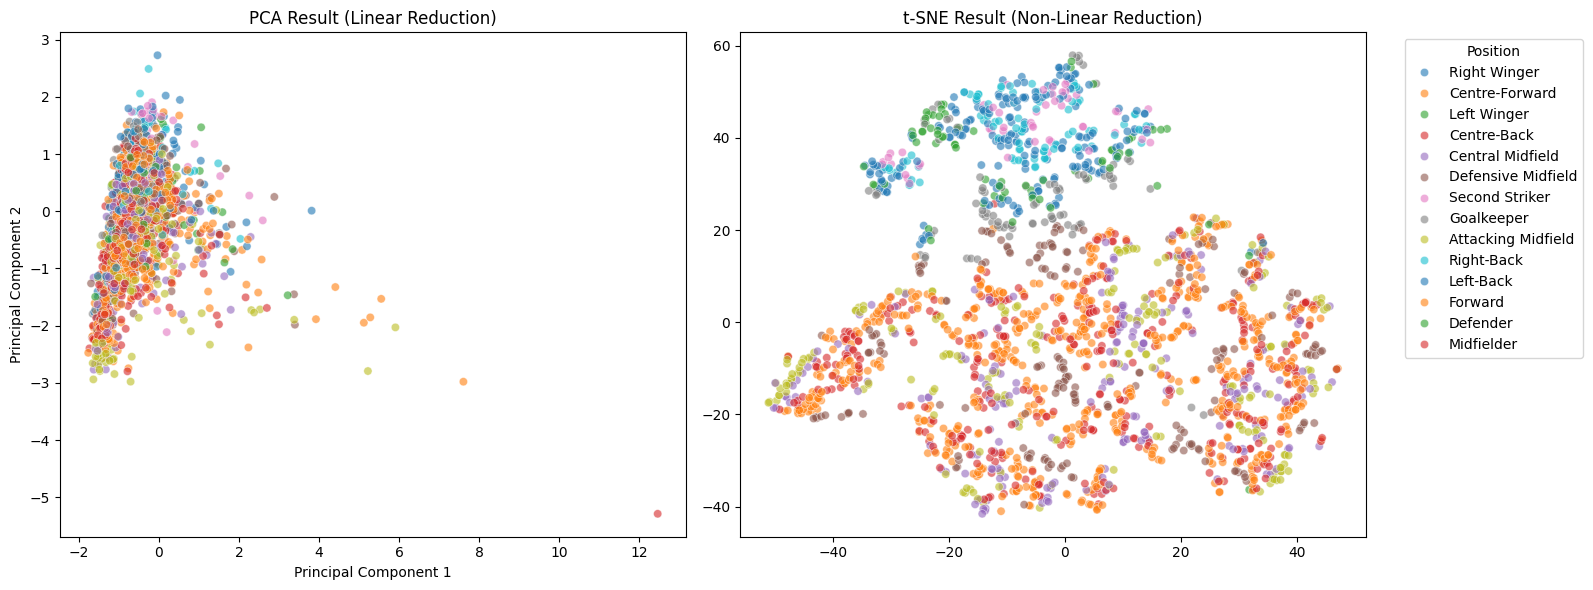

In [29]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. TYPE CONVERSION & FEATURE ENGINEERING
# =========================================================

# Extract Start Year from Season (e.g. '2000-2001' -> 2000)
# We take the first 4 characters and convert to int
df_clean['Season_Year'] = df_clean['Season'].str[:4].astype(int)

# We need to convert text columns to numbers to run PCA
df_pca = df_clean.copy()

# Label Encode Categorical Data
le = LabelEncoder()
cols_to_encode = ['Position', 'League_from', 'League_to', 'Team_from', 'Team_to']
for col in cols_to_encode:
    df_pca[col] = le.fit_transform(df_pca[col])

# Drop non-numeric columns (like Name and original Season)
features = ['Age', 'Position', 'Market_value', 'Transfer_fee', 'Season_Year', 'League_from']
X = df_pca[features]

# SCALE THE DATA (Crucial for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# A. PCA (Standard Linear Reduction)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# B. t-SNE (Non-Linear Reduction - better for clusters)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled[:2000]) # Using first 2000 rows for speed

# --- PLOTTING THE COMPARISON ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:2000, 0], y=X_pca[:2000, 1], hue=df_clean['Position'][:2000], legend=False, palette='tab10', alpha=0.6)
plt.title('PCA Result (Linear Reduction)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_clean['Position'][:2000], legend=True, palette='tab10', alpha=0.6)
plt.title('t-SNE Result (Non-Linear Reduction)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Position')

plt.tight_layout()
plt.show()

## 3.3: Visualization & Verification

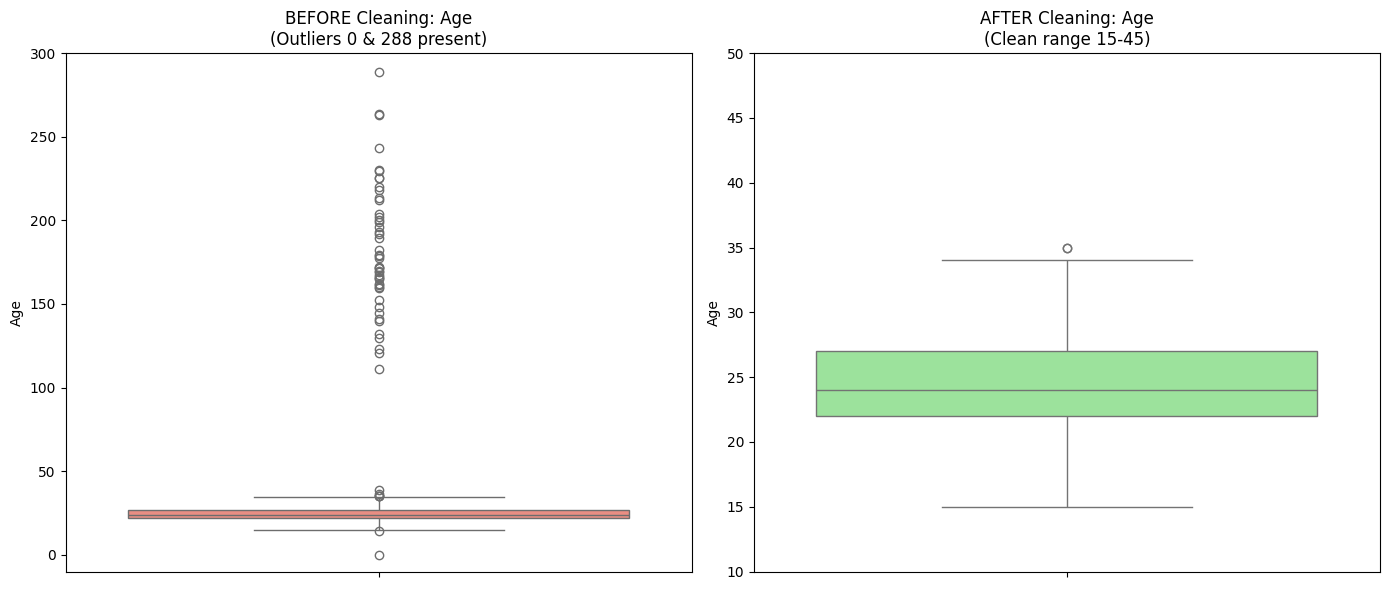

=== Final Verification ===
Missing Values in Clean Data: 0
Age Range: 15 to 35


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# --- Chart 1: BEFORE (From original df) ---
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='salmon')
plt.title('BEFORE Cleaning: Age\n(Outliers 0 & 288 present)')
plt.ylim(-10, 300) # Zoom out to see the 288 error

# --- Chart 2: AFTER (From df_clean) ---
plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['Age'], color='lightgreen')
plt.title('AFTER Cleaning: Age\n(Clean range 15-45)')
plt.ylim(10, 50) # Normal football age range

plt.tight_layout()
plt.show()

# --- Verification Stats ---
print("=== Final Verification ===")
print(f"Missing Values in Clean Data: {df_clean.isnull().sum().sum()}")
print(f"Age Range: {df_clean['Age'].min()} to {df_clean['Age'].max()}")